# Bayesian Role Coordination in Cooperative Multi-Agent Systems

**A Tutorial on Probabilistic Inference for Hidden Role Discovery**

---

## Introduction

### The Problem

Imagine a team of agents who must coordinate to defeat a powerful enemy. Success requires complementary roles:
- **Fighters** deal damage
- **Tanks** absorb attacks
- **Healers** restore health

But here's the challenge: **agents don't know each other's roles**. They can only observe each other's actions and must infer who should do what through Bayesian reasoning.

### Why This Matters

This scenario captures core challenges in **rational cooperative AI**:
1. **Hidden states**: Agents have private information (their capabilities/intentions)
2. **Coordination**: Success requires complementary behaviors, not just individual optimization
3. **Inference**: Agents must reason about teammates probabilistically
4. **Common knowledge**: Shared priors and models enable coordination without communication

Real-world applications include:
- Robot teams with uncertain capabilities
- Distributed systems with role specialization
- Human-AI teams where AI must infer human intent
- Multi-agent reinforcement learning with emergent roles

---

## Learning Outcomes

By working through this tutorial, you will:

1. **Understand Bayesian role inference**: How agents update beliefs about hidden roles using observed actions
2. **Use probabilistic programming**: Implement inference models with the `memo` framework
3. **Analyze coordination dynamics**: See how initial beliefs (priors) affect convergence and success
4. **Scale to complexity**: Generalize from 3 to N agents with parameterized models
5. **Design experiments**: Compare different prior initialization strategies systematically

---

## Tutorial Roadmap

**Progressive Complexity**:

- **Part 1**: Core mechanics with 3 players (basic game + inference)
- **Part 2**: **MAIN RESEARCH QUESTION** - How do different priors affect coordination?
  - Uniform vs. utility-based vs. constrained priors
  - Full experimental comparison with metrics and visualizations
- **Part 3**: Generalization to N players (4, 5, 6+ agents)
- **Part 4**: Stat differentiation effects (specialist vs. generalist teams) *[Placeholder]*
- **Part 5**: Difficulty scaling (easy vs. hard bosses) *[Placeholder]*
- **Part 6**: Conclusion and extensions

**Estimated time**: 30-40 minutes to read and run all cells

Let's begin!

---

# Part 1: Core Mechanics (3 Players)

We'll start with the simplest version: 3 players, 3 roles, and a single enemy to defeat.

## 1.1 Imports and Setup

In [795]:
from memo import memo
import jax
import jax.numpy as np
from enum import IntEnum
import random
import matplotlib.pyplot as plt
import numpy as onp
from scipy.stats import entropy
from dataclasses import dataclass
from typing import List, Tuple, Optional
import time

# Set random seeds for reproducibility
DEMO_SEED = 46
random.seed(DEMO_SEED)
jax_key = jax.random.PRNGKey(DEMO_SEED)

## 1.2 Game Setup: Roles, Actions, and Health States

### Roles
Each player can adopt one of three roles:
- **Fighter**: Specializes in attacking (high STR)
- **Tank**: Specializes in defense (high DEF)
- **Healer**: Specializes in support (high SUP)

### Actions
Each turn, players choose one action:
- **Attack**: Deal damage to enemy
- **Defend**: Protect team from enemy attacks
- **Heal**: Restore team health

### Health States
Both enemy and team health progress through 5 states:
- **DEAD** (0) → **LOW** (1) → **MEDIUM** (2) → **HIGH** (3) → **FULL** (4)

**Victory condition**: Reduce enemy health to DEAD  
**Loss condition**: Team health drops to DEAD  
**Draw**: Max timesteps reached without resolution

In [796]:
# Define game entities as enums
class Role(IntEnum):
    Fighter = 0
    Tank = 1
    Healer = 2

class Action(IntEnum):
    Attack = 0
    Defend = 1
    Heal = 2

class EnemyHealth(IntEnum):
    DEAD = 0
    LOW = 1
    MEDIUM = 2
    HIGH = 3
    FULL = 4

class TeamHealth(IntEnum):
    DEAD = 0
    LOW = 1
    MEDIUM = 2
    HIGH = 3
    FULL = 4

# Configuration for a 3-player game
N_PLAYERS_V1 = 3
N_ROLES_V1 = 3
N_ACTIONS_V1 = 3

## 1.3 Role Policies: How Roles Choose Actions

Each role has a **policy** - a probability distribution over actions given the current game state.

**Key insight**: Roles adapt their behavior based on both enemy and team health:
- Fighters attack more aggressively when the enemy is weak
- Tanks defend more when the enemy is dangerous
- Healers heal more when the team is injured

This creates **informative signals**: if you see someone attacking constantly while the enemy is at FULL health, they're probably a Fighter!

In [797]:
# ROLE_ACTION_STATE_PROBS[role, enemy_health, team_health, action]
# Probabilities: P(action | role, enemy_health, team_health)
ROLE_ACTION_STATE_PROBS_V1 = np.array([
    # Fighter probabilities [enemy_health, team_health, action]
    # Base: Attack 0.90, adapts based on game state
    # - Higher attack when enemy is LOW (easier target) or team is HIGH (confident)
    # - Lower attack when enemy is HIGH (harder target) or team is LOW (more cautious)
    [
        # enemy DEAD - random regardless of team health
        [[0.33, 0.33, 0.34], [0.33, 0.33, 0.34], [0.33, 0.33, 0.34], [0.33, 0.33, 0.34], [0.33, 0.33, 0.34]],
        # enemy LOW, team: [DEAD, LOW, MEDIUM, HIGH, FULL]
        [[0.33, 0.33, 0.34], [0.90, 0.06, 0.04], [0.90, 0.06, 0.04], [0.90, 0.06, 0.04], [0.90, 0.06, 0.04]],
        # enemy MEDIUM, team: [DEAD, LOW, MEDIUM, HIGH, FULL]
        [[0.33, 0.33, 0.34], [0.60, 0.25, 0.15], [0.90, 0.06, 0.04], [0.90, 0.06, 0.04], [0.90, 0.06, 0.04]],
        # enemy HIGH, team: [DEAD, LOW, MEDIUM, HIGH, FULL]
        [[0.33, 0.33, 0.34], [0.50, 0.30, 0.20], [0.70, 0.18, 0.12], [0.90, 0.06, 0.04], [0.90, 0.06, 0.04]],
        # enemy FULL, team: [DEAD, LOW, MEDIUM, HIGH, FULL]
        [[0.33, 0.33, 0.34], [0.40, 0.35, 0.25], [0.60, 0.25, 0.15], [0.80, 0.12, 0.08], [0.90, 0.06, 0.04]],
    ],
    # Tank probabilities [enemy_health, team_health, action]
    # Base: Defend 0.90, adapts based on game state
    # - Higher defend when team is LOW (protect team) or enemy is HIGH (more threatening)
    # - Lower defend when team is HIGH (less protection needed) or enemy is LOW (less threatening)
    [
        # enemy DEAD - random regardless of team health
        [[0.33, 0.33, 0.34], [0.33, 0.33, 0.34], [0.33, 0.33, 0.34], [0.33, 0.33, 0.34], [0.33, 0.33, 0.34]],
        # enemy LOW, team: [DEAD, LOW, MEDIUM, HIGH, FULL]
        [[0.33, 0.33, 0.34], [0.10, 0.75, 0.15], [0.15, 0.70, 0.15], [0.20, 0.65, 0.15], [0.25, 0.60, 0.15]],
        # enemy MEDIUM, team: [DEAD, LOW, MEDIUM, HIGH, FULL]
        [[0.33, 0.33, 0.34], [0.08, 0.82, 0.10], [0.10, 0.80, 0.10], [0.15, 0.75, 0.10], [0.20, 0.70, 0.10]],
        # enemy HIGH, team: [DEAD, LOW, MEDIUM, HIGH, FULL]
        [[0.33, 0.33, 0.34], [0.05, 0.88, 0.07], [0.06, 0.86, 0.08], [0.08, 0.84, 0.08], [0.10, 0.82, 0.08]],
        # enemy FULL, team: [DEAD, LOW, MEDIUM, HIGH, FULL]
        [[0.33, 0.33, 0.34], [0.04, 0.90, 0.06], [0.04, 0.88, 0.08], [0.06, 0.86, 0.08], [0.08, 0.84, 0.08]],
    ],
    # Healer probabilities [enemy_health, team_health, action]
    # Base: Heal 0.90, adapts based on game state
    # - Higher heal when team is LOW (team needs healing)
    # - Lower heal when team is HIGH (team doesn't need healing)
    # - Consistent across enemy health (always focused on healing regardless of enemy state)
    [
        # enemy DEAD - random regardless of team health
        [[0.33, 0.33, 0.34], [0.33, 0.33, 0.34], [0.33, 0.33, 0.34], [0.33, 0.33, 0.34], [0.33, 0.33, 0.34]],
        # enemy LOW, team: [DEAD, LOW, MEDIUM, HIGH, FULL]
        [[0.33, 0.33, 0.34], [0.05, 0.05, 0.90], [0.08, 0.07, 0.85], [0.10, 0.10, 0.80], [0.15, 0.15, 0.70]],
        # enemy MEDIUM, team: [DEAD, LOW, MEDIUM, HIGH, FULL]
        [[0.33, 0.33, 0.34], [0.05, 0.05, 0.90], [0.08, 0.07, 0.85], [0.10, 0.10, 0.80], [0.15, 0.15, 0.70]],
        # enemy HIGH, team: [DEAD, LOW, MEDIUM, HIGH, FULL]
        [[0.33, 0.33, 0.34], [0.05, 0.05, 0.90], [0.08, 0.07, 0.85], [0.10, 0.10, 0.80], [0.15, 0.15, 0.70]],
        # enemy FULL, team: [DEAD, LOW, MEDIUM, HIGH, FULL]
        [[0.33, 0.33, 0.34], [0.05, 0.05, 0.90], [0.08, 0.07, 0.85], [0.10, 0.10, 0.80], [0.15, 0.15, 0.70]],
    ],
])

@jax.jit
def role_policy_v1(role, action, enemy_health, team_health):
    """Get probability of action given role and game state."""
    return ROLE_ACTION_STATE_PROBS_V1[role, enemy_health, team_health, action]

## 1.4 Stats System: Individual Capabilities

Each player has three stats that sum to 1.0:
- **STR** (Strength): Boosts attack effectiveness
- **DEF** (Defense): Boosts defend effectiveness
- **SUP** (Support): Boosts heal effectiveness

**Example**:
- Player with [0.7, 0.2, 0.1] is naturally suited to be a Fighter
- Player with [0.1, 0.7, 0.2] is naturally suited to be a Tank
- Player with [0.2, 0.1, 0.7] is naturally suited to be a Healer

Stats affect the **transition probabilities**: a team with high total STR deals more damage!

In [798]:
def generate_player_stats(player_id, seed=42, mode='random'):
    """
    Generate player stats [STR, DEF, SUP] that sum to 1.0.
    
    Args:
        player_id: Unique identifier for reproducibility
        seed: Random seed
        mode: 'random' (Dirichlet), 'balanced' (0.33 each), 'extreme' (0.8+ in one stat)
    """
    random.seed(seed + player_id)
    
    if mode == 'balanced':
        return np.array([0.33, 0.33, 0.34])
    elif mode == 'extreme':
        # Put 0.8-0.9 in one stat, split remainder
        dominant_idx = player_id % 3
        dominant_val = 0.8 + random.random() * 0.15  # 0.8 to 0.95
        remainder = 1.0 - dominant_val
        other_val = remainder / 2
        stats = [other_val, other_val, other_val]
        stats[dominant_idx] = dominant_val
        return np.array(stats)
    else:  # 'random' - Dirichlet distribution
        alpha = [1.0, 1.0, 1.0]
        raw_stats = [random.gammavariate(a, 1.0) for a in alpha]
        total = sum(raw_stats)
        return np.array([s / total for s in raw_stats])

# Example: Generate stats for 3 players
print("Example player stats:")
for i in range(3):
    stats = generate_player_stats(i, seed=42)
    best_role = Role(int(np.argmax(stats))).name
    print(f"Player {i}: STR={stats[0]:.2f}, DEF={stats[1]:.2f}, SUP={stats[2]:.2f} → Best: {best_role}")

Example player stats:
Player 0: STR=0.75, DEF=0.02, SUP=0.24 → Best: Fighter
Player 1: STR=0.03, DEF=0.86, SUP=0.11 → Best: Tank
Player 2: STR=0.16, DEF=0.24, SUP=0.60 → Best: Healer


## 1.5 Transition Dynamics: How Actions Affect Health

Each turn:
1. **Enemy health** may decrease (more attackers → more damage)
2. **Team health** may decrease (enemy attacks based on health state)
3. **Team health** may increase (more healers → more healing)

Base probabilities are modified by player stats:
- High total STR among attackers → better damage rolls
- High total DEF among defenders → better damage mitigation
- High total SUP among healers → better healing rolls

In [799]:
# Base transition probabilities (for "average" stats of 0.33 each, normal difficulty)
ENEMY_DAMAGE_BASE_PROBS = np.array([
    [0.0, 0.30, 0.70],   # 0 attackers: 70% enemy heals, 30% stay
    [0.30, 0.60, 0.10],  # 1 attacker: 30% damage
    [0.50, 0.40, 0.10],  # 2 attackers: 50% damage
    [0.70, 0.25, 0.05],  # 3 attackers: 70% damage
])

TEAM_DAMAGE_BASE_PROBS = np.array([
    [0.70, 0.25, 0.05],  # 0 defenders: 70% take damage
    [0.40, 0.50, 0.10],  # 1 defender: 40% take damage
    [0.20, 0.60, 0.20],  # 2 defenders: 20% take damage
    [0.05, 0.70, 0.25],  # 3 defenders: 5% take damage
])

TEAM_HEAL_BASE_PROBS = np.array([
    [0.0, 0.90, 0.10],   # 0 healers: 10% natural regen
    [0.0, 0.40, 0.60],   # 1 healer: 60% gain health
    [0.0, 0.20, 0.80],   # 2 healers: 80% gain health
    [0.0, 0.10, 0.90],   # 3 healers: 90% gain health
])

# Enemy attack probability based on enemy health (healthier = more aggressive)
ENEMY_ATTACK_PROB = np.array([0.25, 0.40, 0.55, 0.65, 0.75])

def scale_probs_for_difficulty(probs, difficulty, favor_first):
    """
    Scale transition probabilities based on difficulty.
    
    Args:
        probs: Base probability array [decrease, stay, increase]
        difficulty: Multiplier (0.7=easy, 1.0=normal, 1.3=hard)
        favor_first: If True, boost first prob (damage). If False, reduce it.
    
    Returns:
        Scaled probabilities that sum to 1.0
    """
    if favor_first:
        # Higher difficulty → more likely to take first outcome (damage/heal)
        p_first = probs[0] * difficulty
        p_last = probs[2] / difficulty
    else:
        # Higher difficulty → less likely to take first outcome
        p_first = probs[0] / difficulty
        p_last = probs[2] * difficulty
    
    # Normalize
    scaled = np.array([p_first, 0.0, p_last])
    total = scaled[0] + scaled[2]
    p_mid = np.maximum(0.0, 1.0 - total)
    result = np.array([scaled[0], p_mid, scaled[2]])
    return result / np.sum(result)

@jax.jit
def modify_probs_with_stats(base_probs, relevant_stats, boost_decrease):
    """
    Modify transition probabilities based on player stats.
    
    Args:
        base_probs: Base probability array [decrease, stay, increase]
        relevant_stats: Sum of relevant stats (e.g., total STR of attackers)
        boost_decrease: True to boost "decrease" prob, False to boost "increase" prob
    
    Returns:
        Modified probabilities that sum to 1.0
    """
    # Stats range from 0 to 3 (if all 3 players have 1.0 in that stat)
    # Average stats would be ~1.0 (3 players * 0.33 average)
    # Modifier ranges from 0.5 (weak) to 1.5 (strong)
    stat_modifier = 0.5 + (relevant_stats / 3.0)
    
    def boost_decrease_fn():
        decrease_prob = base_probs[0] * stat_modifier
        increase_prob = base_probs[2] / stat_modifier
        return np.array([decrease_prob, 0.0, increase_prob])
    
    def boost_increase_fn():
        decrease_prob = base_probs[0] / stat_modifier
        increase_prob = base_probs[2] * stat_modifier
        return np.array([decrease_prob, 0.0, increase_prob])
    
    modified = jax.lax.cond(boost_decrease, boost_decrease_fn, boost_increase_fn)
    
    # Stay probability adjusts to maintain sum = 1.0
    total = modified[0] + modified[2]
    stay_prob = np.maximum(0.0, 1.0 - total)
    
    # Normalize
    probs = np.array([modified[0], stay_prob, modified[2]])
    return probs / np.sum(probs)

@jax.jit
def transition(enemy_health, team_health, actions, stats, key, difficulty=1.0):
    """
    Update both enemy and team health based on actions and player stats.
    
    Args:
        enemy_health: Current enemy health state (0=DEAD to 4=FULL)
        team_health: Current team health state (0=DEAD to 4=FULL)
        actions: Array of 3 actions [a0, a1, a2]
        stats: Array of player stats [3, 3] where stats[i] = [STR, DEF, SUP]
        key: JAX random key
        difficulty: Boss difficulty (0.7=easy, 1.0=normal, 1.3=hard)
    
    Returns:
        (next_enemy_health, next_team_health)
    """
    key1, key2, key3 = jax.random.split(key, 3)
    
    # Identify action types and sum relevant stats
    attacker_mask = (actions == Action.Attack).astype(np.float32)
    defender_mask = (actions == Action.Defend).astype(np.float32)
    healer_mask = (actions == Action.Heal).astype(np.float32)
    
    total_attack_str = np.sum(attacker_mask * stats[:, 0])  # STR of attackers
    total_defend_def = np.sum(defender_mask * stats[:, 1])  # DEF of defenders
    total_heal_sup = np.sum(healer_mask * stats[:, 2])      # SUP of healers
    
    num_attackers = np.clip(np.sum(attacker_mask).astype(np.int32), 0, 3)
    num_defenders = np.clip(np.sum(defender_mask).astype(np.int32), 0, 3)
    num_healers = np.clip(np.sum(healer_mask).astype(np.int32), 0, 3)
    
    # ENEMY HEALTH UPDATE (harder = more enemy healing, less damage)
    base_enemy_probs = ENEMY_DAMAGE_BASE_PROBS[num_attackers]
    # Scale for difficulty: higher difficulty = enemy harder to kill
    difficulty_scaled_enemy = scale_probs_for_difficulty(base_enemy_probs, difficulty, False)
    enemy_probs = modify_probs_with_stats(difficulty_scaled_enemy, total_attack_str, True)
    enemy_change = jax.random.choice(key1, np.array([-1, 0, 1]), p=enemy_probs)
    next_enemy_health = np.clip(enemy_health + enemy_change, 0, 4)
    
    # TEAM HEALTH UPDATE (damage) - harder = more damage to team
    enemy_attack_prob_scaled = ENEMY_ATTACK_PROB[enemy_health] * (0.7 + 0.3 * difficulty)
    enemy_attacks = jax.random.uniform(key2) < enemy_attack_prob_scaled
    base_damage_probs = TEAM_DAMAGE_BASE_PROBS[num_defenders]
    # Scale for difficulty: higher difficulty = more damage to team
    difficulty_scaled_damage = scale_probs_for_difficulty(base_damage_probs, difficulty, True)
    damage_probs = modify_probs_with_stats(difficulty_scaled_damage, total_defend_def, True)
    
    damage_change = jax.lax.cond(
        enemy_attacks,
        lambda: jax.random.choice(key3, np.array([-1, 0, 1]), p=damage_probs),
        lambda: 0
    )
    
    # TEAM HEALTH UPDATE (healing) - difficulty doesn't affect healing directly
    base_heal_probs = TEAM_HEAL_BASE_PROBS[num_healers]
    heal_probs = modify_probs_with_stats(base_heal_probs, total_heal_sup, False)
    key_heal = jax.random.fold_in(key3, 1)
    heal_change = jax.random.choice(key_heal, np.array([-1, 0, 1]), p=heal_probs)
    
    # Apply both changes simultaneously
    total_change = damage_change + heal_change
    next_team_health = np.clip(team_health + total_change, 0, 4)
    
    return next_enemy_health, next_team_health

## 1.6 Bayesian Inference with Memo

Now for the key mechanism: **how do agents infer each other's roles?**

### The `memo` Framework

`memo` is a probabilistic programming language that lets us express generative models and perform inference.

**Key concepts**:
- `observer`: The agent doing the reasoning
- `observer: thinks[...]`: The observer's model of how the world works
- `team: assigned(...)`: Sample a value according to some distribution (here, roles)
- `team: chooses(...)`: Sample an action according to a policy
- `observer: observes_that [condition]`: Condition on observed evidence
- `observer[Pr[query]]`: Compute posterior probability of a query

### Our Inference Model

The observer thinks:
1. The team has some role assignment (prior distribution)
2. Each player chooses actions according to their role policy
3. We observe the actual actions taken
4. **Question**: What's the posterior probability of each role assignment?

This is standard Bayesian inference: `P(roles | actions) ∝ P(actions | roles) × P(roles)`

In [800]:
# Helper function to extract element from 3D array (memo limitation)
@jax.jit
def get_element(array, i0, i1, i2):
    return array[i0, i1, i2]

@memo
def role_inference_v1[r0: Role, r1: Role, r2: Role](
    role_prior, obs_a0, obs_a1, obs_a2, enemy_health, team_health
):
    """
    Infer role probabilities given observed actions and game state.
    
    Args:
        role_prior: 3x3x3 array of prior probabilities P(r0, r1, r2)
        obs_a0, obs_a1, obs_a2: Observed actions for players 0, 1, 2
        enemy_health: Current enemy health state
        team_health: Current team health state
    
    Returns:
        3x3x3 array of posterior probabilities P(r0, r1, r2 | actions, state)
    """
    observer: knows(r0, r1, r2)  # Push array indices into observer's frame
    
    # Observer's generative model
    observer: thinks[
        # Sample role assignment according to prior
        team: assigned(
            r0 in Role, r1 in Role, r2 in Role,
            wpp=get_element(role_prior, r0, r1, r2)
        ),
        # Each player chooses action according to their role policy
        team: chooses(a0 in Action, wpp=role_policy_v1(r0, a0, enemy_health, team_health)),
        team: chooses(a1 in Action, wpp=role_policy_v1(r1, a1, enemy_health, team_health)),
        team: chooses(a2 in Action, wpp=role_policy_v1(r2, a2, enemy_health, team_health))
    ]
    
    # Condition on observed actions
    observer: observes_that [team.a0 == obs_a0]
    observer: observes_that [team.a1 == obs_a1]
    observer: observes_that [team.a2 == obs_a2]
    
    # Return posterior probability of this role assignment
    return observer[Pr[r0 == team.r0 and r1 == team.r1 and r2 == team.r2]]

print("Bayesian inference model defined!")
print("Given: observed actions + game state")
print("Returns: P(role assignment | observations)")

Bayesian inference model defined!
Given: observed actions + game state
Returns: P(role assignment | observations)


### Creating Role Priors

The prior distribution P(roles) encodes initial beliefs about role assignments.

We'll implement three types:
1. **Uniform**: All 27 assignments equally likely (no preferences)
2. **Utility-based (unconstrained)**: Prefer assignments where players match their best stats (allows duplicates)
3. **Utility-based (constrained)**: Same but enforce unique roles (only 6 valid assignments)


Prior comparison for specialist team:
Uniform prior: All 27 assignments have prob 0.0370

Unconstrained utility prior (top 3):
  (Fighter, Tank, Healer): 0.2151
  (Fighter, Tank, Tank): 0.0791
  (Fighter, Fighter, Healer): 0.0791

Constrained utility prior (all 6):
  (Fighter, Tank, Healer): 0.7087
  (Tank, Fighter, Healer): 0.0959
  (Fighter, Healer, Tank): 0.0785
  (Healer, Tank, Fighter): 0.0643
  (Healer, Fighter, Tank): 0.0289
  (Tank, Healer, Fighter): 0.0237


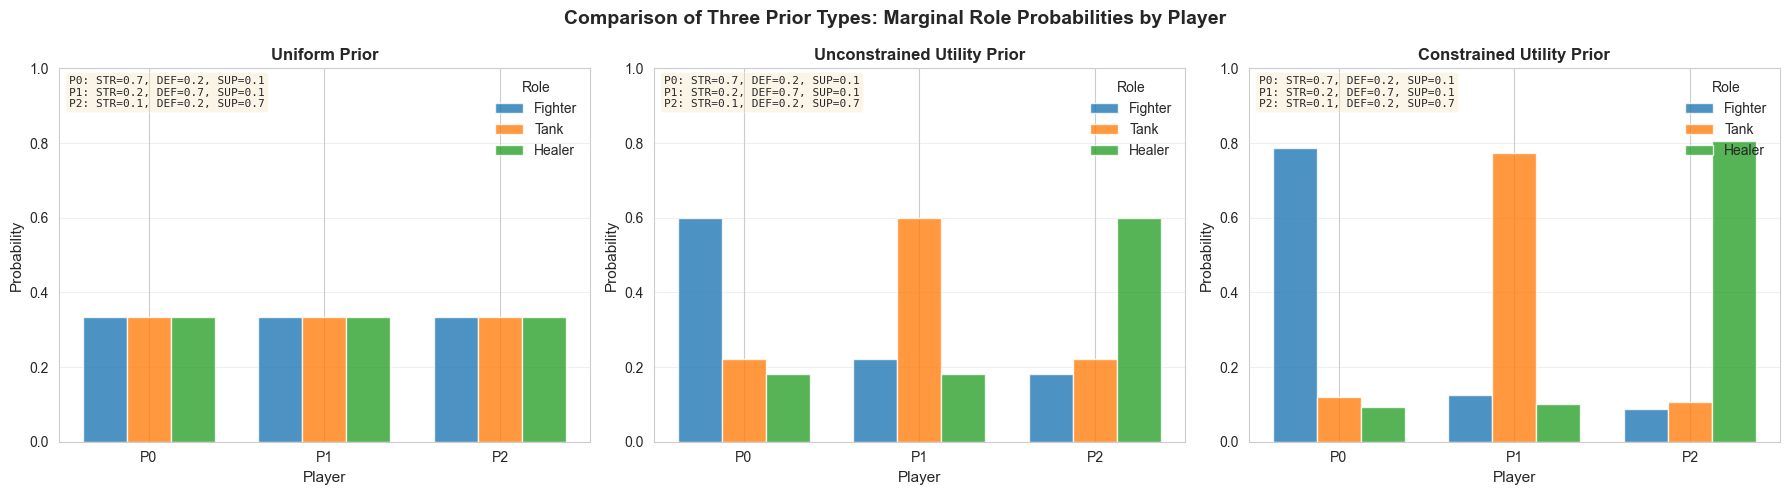

In [801]:
def uniform_prior_v1():
    """All role assignments equally likely."""
    prior = np.ones((3, 3, 3))
    return prior / np.sum(prior)

def utility_based_prior_v1(player_stats_list, temperature=0.5, constrained=False):
    """
    Create role prior based on player stats.
    
    Args:
        player_stats_list: List of 3 arrays, each [STR, DEF, SUP]
        temperature: Higher = flatter distribution (more uncertainty)
        constrained: If True, enforce unique roles (only 6 valid assignments)
    
    Returns:
        prior: 3x3x3 array where prior[r0, r1, r2] = P(player0=r0, player1=r1, player2=r2)
    """
    prior = np.zeros((3, 3, 3))
    
    for r0 in range(3):
        for r1 in range(3):
            for r2 in range(3):
                # Check uniqueness constraint if needed
                if constrained and len({r0, r1, r2}) != 3:
                    continue  # Skip duplicate role assignments
                
                # Utility: how well each player fits their assigned role
                u0 = player_stats_list[0][r0]  # Player 0's stat for role r0
                u1 = player_stats_list[1][r1]  # Player 1's stat for role r1
                u2 = player_stats_list[2][r2]  # Player 2's stat for role r2
                
                total_utility = u0 + u1 + u2
                utility = np.exp(total_utility / temperature)
                prior = prior.at[r0, r1, r2].set(utility)
    
    # Normalize
    return prior / np.sum(prior)

# Example: Compare priors
example_stats = [
    np.array([0.7, 0.2, 0.1]),  # Player 0: Strong fighter
    np.array([0.2, 0.7, 0.1]),  # Player 1: Strong tank
    np.array([0.1, 0.2, 0.7]),  # Player 2: Strong healer
]

uniform = uniform_prior_v1()
utility_uncon = utility_based_prior_v1(example_stats, temperature=0.5, constrained=False)
utility_con = utility_based_prior_v1(example_stats, temperature=0.5, constrained=True)

print("\nPrior comparison for specialist team:")
print(f"Uniform prior: All 27 assignments have prob {float(uniform[0,0,0]):.4f}")
print(f"\nUnconstrained utility prior (top 3):")
flat = [(r0,r1,r2, float(utility_uncon[r0,r1,r2])) for r0 in range(3) for r1 in range(3) for r2 in range(3)]
flat.sort(key=lambda x: x[3], reverse=True)
for r0,r1,r2,p in flat[:3]:
    print(f"  ({Role(r0).name}, {Role(r1).name}, {Role(r2).name}): {p:.4f}")

print(f"\nConstrained utility prior (all 6):")
flat_con = [(r0,r1,r2, float(utility_con[r0,r1,r2])) for r0 in range(3) for r1 in range(3) for r2 in range(3) if utility_con[r0,r1,r2] > 0]
flat_con.sort(key=lambda x: x[3], reverse=True)
for r0,r1,r2,p in flat_con:
    print(f"  ({Role(r0).name}, {Role(r1).name}, {Role(r2).name}): {p:.4f}")

# Visualize the three different priors
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

priors = [
    (uniform, 'Uniform Prior'),
    (utility_uncon, 'Unconstrained Utility Prior'),
    (utility_con, 'Constrained Utility Prior')
]

for ax_idx, (prior, title) in enumerate(priors):
    ax = axes[ax_idx]
    
    # Extract marginal probabilities for each player
    marginals = []
    for player in range(3):
        marginal = marginalize(prior, player)
        marginals.append(marginal)
    
    # Plot as grouped bar chart
    x = onp.arange(3)  # Players 0, 1, 2
    width = 0.25
    
    for role_idx, role in enumerate(Role):
        role_probs = [marginals[player][role_idx] for player in range(3)]
        ax.bar(x + (role_idx - 1) * width, role_probs, width, 
               label=role.name, alpha=0.8)
    
    ax.set_xlabel('Player', fontsize=11)
    ax.set_ylabel('Probability', fontsize=11)
    ax.set_title(title, fontsize=12, fontweight='bold')
    ax.set_xticks(x)
    ax.set_xticklabels([f'P{i}' for i in range(3)])
    ax.legend(title='Role', frameon=False)
    ax.set_ylim([0, 1.0])
    ax.grid(True, alpha=0.3, axis='y')
    
    # Add player stats as text
    stats_text = '\n'.join([f'P{i}: STR={example_stats[i][0]:.1f}, DEF={example_stats[i][1]:.1f}, SUP={example_stats[i][2]:.1f}' 
                           for i in range(3)])
    ax.text(0.02, 0.98, stats_text, transform=ax.transAxes,
            fontsize=8, verticalalignment='top', family='monospace',
            bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.3))

plt.suptitle('Comparison of Three Prior Types: Marginal Role Probabilities by Player', 
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

## 1.7 Simulation Framework

Now we can put it all together: simulate a full game where agents infer roles over time.

In [802]:
def marginalize(probs, keepaxis):
    """Extract marginal probability for a single player."""
    return np.sum(probs, axis=tuple(i for i in range(probs.ndim) if i != keepaxis))

def simulate_game_v1(
    n_steps,
    player_stats,
    role_prior,
    initial_enemy_health=EnemyHealth.FULL,
    initial_team_health=TeamHealth.FULL,
    difficulty=1.0,
    seed=42
):
    """
    Simulate the role coordination game.
    
    Args:
        n_steps: Maximum number of timesteps
        player_stats: List of 3 stat arrays
        role_prior: 3x3x3 prior distribution
        initial_enemy_health: Starting enemy health
        initial_team_health: Starting team health
        difficulty: Boss difficulty (0.7=easy, 1.0=normal, 1.3=hard)
        seed: Random seed
    
    Returns:
        Dictionary with:
        - role_history: [T x 3] sampled roles
        - action_history: [T x 3] sampled actions
        - role_prob_history: [T x 3 x 3 x 3] role beliefs
        - enemy_health_history: [T+1] enemy health states
        - team_health_history: [T+1] team health states
        - n_steps: Actual steps taken
        - outcome: 'WIN', 'LOSE', or 'DRAW'
    """
    random.seed(seed)
    key = jax.random.PRNGKey(seed)
    
    # Initialize
    role_probs = role_prior
    enemy_health = initial_enemy_health
    team_health = initial_team_health
    
    # History arrays
    role_history = []
    action_history = []
    role_prob_history = []
    enemy_health_history = [enemy_health]
    team_health_history = [team_health]
    
    for t in range(n_steps):
        # Sample roles from marginal beliefs
        roles = [random.choices([0,1,2], weights=marginalize(role_probs, i))[0] for i in range(3)]
        role_history.append(roles)
        
        # Sample actions from role policies
        actions = [
            random.choices([0,1,2], weights=ROLE_ACTION_STATE_PROBS_V1[r, enemy_health, team_health, :])[0]
            for r in roles
        ]
        action_history.append(actions)
        
        # Update beliefs via Bayesian inference
        role_probs = role_inference_v1(
            role_probs, *actions,
            enemy_health=enemy_health,
            team_health=team_health
        )
        role_prob_history.append(role_probs)
        
        # Update game state with difficulty
        key, subkey = jax.random.split(key)
        stats_array = np.array(player_stats)
        enemy_health, team_health = transition(
            enemy_health, team_health, np.array(actions), stats_array, subkey, difficulty=difficulty
        )
        
        enemy_health_history.append(enemy_health)
        team_health_history.append(team_health)
        
        # Check termination
        if enemy_health == EnemyHealth.DEAD:
            outcome = "WIN"
            break
        elif team_health == TeamHealth.DEAD:
            outcome = "LOSE"
            break
    else:
        outcome = "DRAW"
    
    return {
        'role_history': np.array(role_history),
        'action_history': np.array(action_history),
        'role_prob_history': np.array(role_prob_history),
        'enemy_health_history': np.array(enemy_health_history),
        'team_health_history': np.array(team_health_history),
        'n_steps': len(role_history),
        'outcome': outcome
    }

## 1.8 Run First Demo

Let's run a single game and visualize what happens!

In [803]:
# Generate player stats
demo_stats = [generate_player_stats(i, seed=DEMO_SEED, mode='extreme') for i in range(3)]

print("DEMO GAME: Player Stats")
print("="*50)
for i, stats in enumerate(demo_stats):
    best_role = Role(int(np.argmax(stats))).name
    print(f"Player {i}: STR={stats[0]:.2f}, DEF={stats[1]:.2f}, SUP={stats[2]:.2f}")
    print(f"  → Best suited for: {best_role}")

# Create utility-based prior (unconstrained)
demo_prior = utility_based_prior_v1(demo_stats, temperature=0.5, constrained=False)

# Run simulation
print("\nRunning simulation...")
result = simulate_game_v1(
    n_steps=200,
    player_stats=demo_stats,
    role_prior=demo_prior,
    seed=DEMO_SEED
)

print(f"\nResult: {result['outcome']}")
print(f"Duration: {result['n_steps']} steps")
print(f"Final Enemy Health: {EnemyHealth(int(result['enemy_health_history'][-1])).name}")
print(f"Final Team Health: {TeamHealth(int(result['team_health_history'][-1])).name}")

DEMO GAME: Player Stats
Player 0: STR=0.93, DEF=0.03, SUP=0.03
  → Best suited for: Fighter
Player 1: STR=0.07, DEF=0.85, SUP=0.07
  → Best suited for: Tank
Player 2: STR=0.06, DEF=0.06, SUP=0.88
  → Best suited for: Healer

Running simulation...

Result: WIN
Duration: 16 steps
Final Enemy Health: DEAD
Final Team Health: FULL


## 1.9 Visualization

Let's create a comprehensive visualization showing:
1. How role beliefs converge over time
2. Health trajectories for enemy and team
3. Action distribution over time
4. Uncertainty (entropy) over time

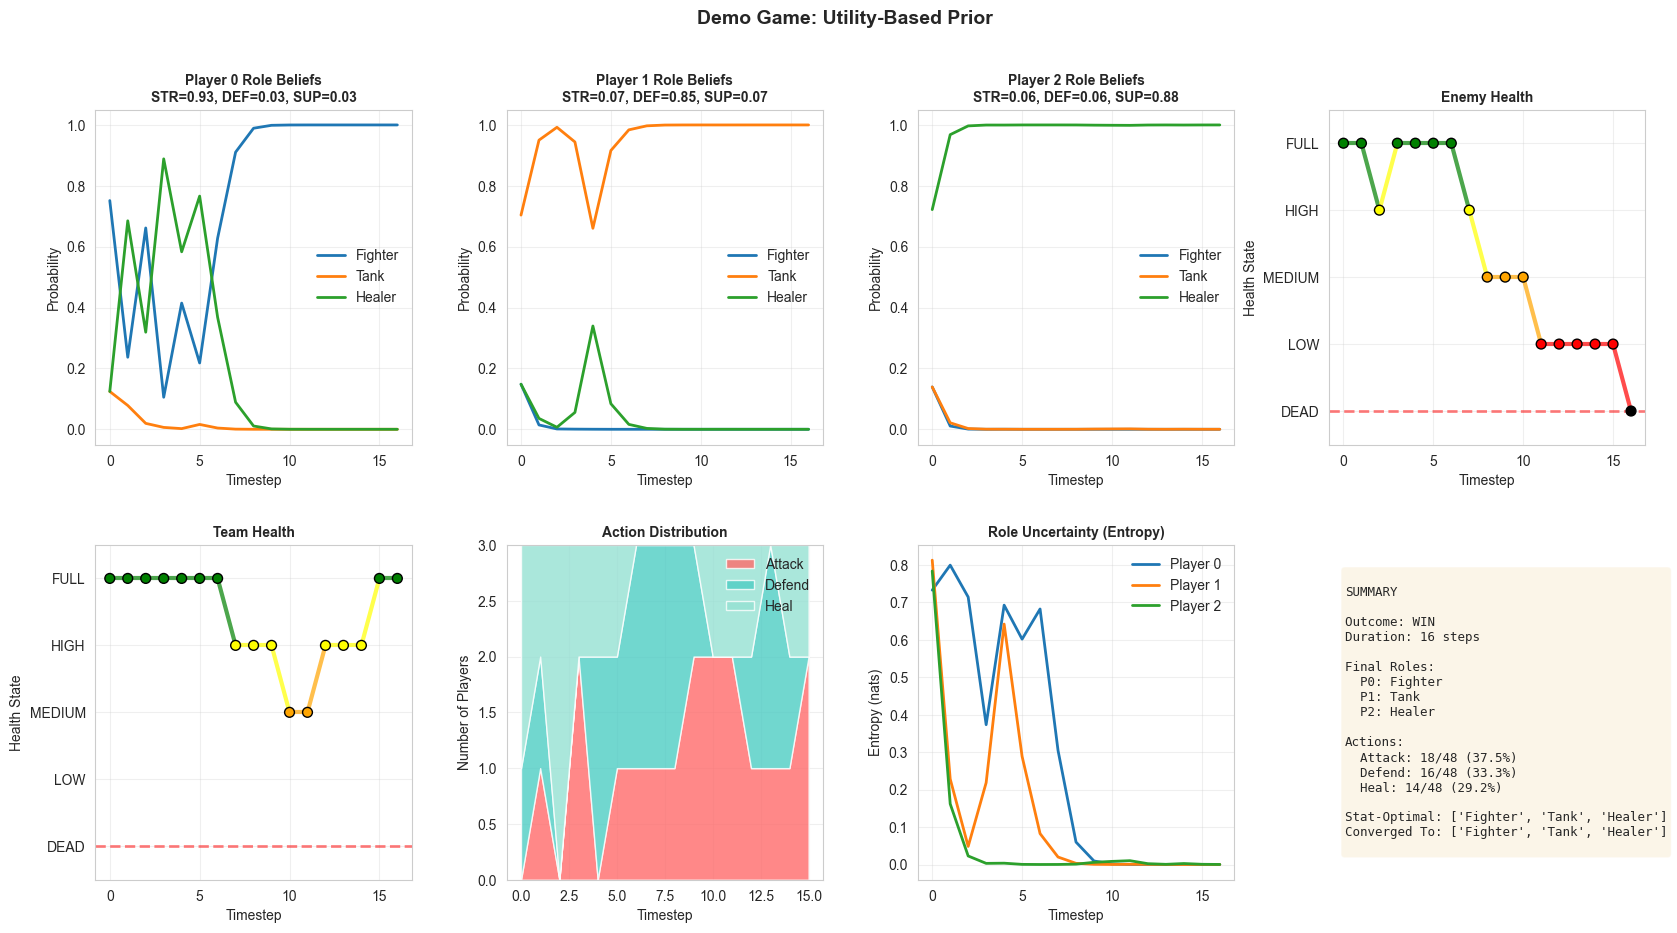

In [804]:
def visualize_game_result(result, player_stats, prior, title="Game Result"):
    """Create comprehensive visualization of game result."""
    fig = plt.figure(figsize=(20, 10))
    gs = fig.add_gridspec(2, 4, hspace=0.3, wspace=0.3)
    
    n_steps = result['n_steps']
    role_prob_history = result['role_prob_history']
    action_history = result['action_history']
    enemy_health_history = result['enemy_health_history']
    team_health_history = result['team_health_history']
    
    # Row 1: Role belief evolution for each player
    for i in range(3):
        ax = fig.add_subplot(gs[0, i])
        
        # Compute marginal probabilities over time
        player_role_probs = [marginalize(role_prob_history[t], i) for t in range(n_steps)]
        # Add initial prior
        initial_marginal = marginalize(prior, i)
        player_role_probs.insert(0, initial_marginal)
        player_role_probs = onp.array(player_role_probs)
        
        # Plot
        for role in Role:
            ax.plot(range(n_steps + 1), player_role_probs[:, role], label=role.name, linewidth=2)
        
        stats = player_stats[i]
        ax.set_title(f'Player {i} Role Beliefs\nSTR={stats[0]:.2f}, DEF={stats[1]:.2f}, SUP={stats[2]:.2f}',
                     fontsize=10, fontweight='bold')
        ax.set_xlabel('Timestep')
        ax.set_ylabel('Probability')
        ax.legend(frameon=False, loc='best')
        ax.grid(True, alpha=0.3)
        ax.set_ylim([-0.05, 1.05])
    
    # Row 1, Col 4: Enemy health
    ax_enemy = fig.add_subplot(gs[0, 3])
    health_names = ['DEAD', 'LOW', 'MEDIUM', 'HIGH', 'FULL']
    health_colors = ['black', 'red', 'orange', 'yellow', 'green']
    
    enemy_health_arr = onp.array(enemy_health_history)
    for i in range(len(enemy_health_arr) - 1):
        color = health_colors[int(enemy_health_arr[i])]
        ax_enemy.plot([i, i+1], [enemy_health_arr[i], enemy_health_arr[i+1]],
                      color=color, linewidth=3, alpha=0.7)
    ax_enemy.scatter(range(len(enemy_health_arr)), enemy_health_arr,
                     c=[health_colors[int(h)] for h in enemy_health_arr],
                     s=50, zorder=3, edgecolors='black', linewidth=1)
    ax_enemy.axhline(y=0, color='red', linestyle='--', linewidth=2, alpha=0.5)
    ax_enemy.set_title('Enemy Health', fontsize=10, fontweight='bold')
    ax_enemy.set_xlabel('Timestep')
    ax_enemy.set_ylabel('Health State')
    ax_enemy.set_yticks(range(5))
    ax_enemy.set_yticklabels(health_names)
    ax_enemy.grid(True, alpha=0.3)
    ax_enemy.set_ylim([-0.5, 4.5])
    
    # Row 2, Col 1: Team health
    ax_team = fig.add_subplot(gs[1, 0])
    team_health_arr = onp.array(team_health_history)
    for i in range(len(team_health_arr) - 1):
        color = health_colors[int(team_health_arr[i])]
        ax_team.plot([i, i+1], [team_health_arr[i], team_health_arr[i+1]],
                     color=color, linewidth=3, alpha=0.7)
    ax_team.scatter(range(len(team_health_arr)), team_health_arr,
                    c=[health_colors[int(h)] for h in team_health_arr],
                    s=50, zorder=3, edgecolors='black', linewidth=1)
    ax_team.axhline(y=0, color='red', linestyle='--', linewidth=2, alpha=0.5)
    ax_team.set_title('Team Health', fontsize=10, fontweight='bold')
    ax_team.set_xlabel('Timestep')
    ax_team.set_ylabel('Health State')
    ax_team.set_yticks(range(5))
    ax_team.set_yticklabels(health_names)
    ax_team.grid(True, alpha=0.3)
    ax_team.set_ylim([-0.5, 4.5])
    
    # Row 2, Col 2: Action distribution
    ax_actions = fig.add_subplot(gs[1, 1])
    action_counts = onp.zeros((n_steps, 3))
    for t in range(n_steps):
        for a in action_history[t]:
            action_counts[t, int(a)] += 1
    
    ax_actions.stackplot(range(n_steps),
                         action_counts[:, 0], action_counts[:, 1], action_counts[:, 2],
                         labels=['Attack', 'Defend', 'Heal'],
                         colors=['#ff6b6b', '#4ecdc4', '#95e1d3'],
                         alpha=0.8)
    ax_actions.set_title('Action Distribution', fontsize=10, fontweight='bold')
    ax_actions.set_xlabel('Timestep')
    ax_actions.set_ylabel('Number of Players')
    ax_actions.legend(loc='upper right', frameon=False)
    ax_actions.grid(True, alpha=0.3)
    ax_actions.set_ylim([0, 3])
    
    # Row 2, Col 3: Role entropy
    ax_entropy = fig.add_subplot(gs[1, 2])
    role_entropy = onp.zeros((n_steps + 1, 3))
    for i in range(3):
        role_entropy[0, i] = entropy(onp.array(marginalize(prior, i)))
        for t in range(n_steps):
            marginal = marginalize(role_prob_history[t], i)
            role_entropy[t + 1, i] = entropy(onp.array(marginal))
    
    for i in range(3):
        ax_entropy.plot(range(n_steps + 1), role_entropy[:, i], label=f'Player {i}', linewidth=2)
    
    ax_entropy.set_title('Role Uncertainty (Entropy)', fontsize=10, fontweight='bold')
    ax_entropy.set_xlabel('Timestep')
    ax_entropy.set_ylabel('Entropy (nats)')
    ax_entropy.legend(frameon=False)
    ax_entropy.grid(True, alpha=0.3)
    
    # Row 2, Col 4: Summary statistics
    ax_stats = fig.add_subplot(gs[1, 3])
    ax_stats.axis('off')
    
    # Calculate final roles
    final_roles = [Role(onp.argmax(onp.array(marginalize(role_prob_history[-1], i)))).name for i in range(3)]
    best_roles = [Role(onp.argmax(player_stats[i])).name for i in range(3)]
    
    # Action totals
    total_attacks = onp.sum([1 for t in range(n_steps) for a in action_history[t] if int(a) == Action.Attack])
    total_defends = onp.sum([1 for t in range(n_steps) for a in action_history[t] if int(a) == Action.Defend])
    total_heals = onp.sum([1 for t in range(n_steps) for a in action_history[t] if int(a) == Action.Heal])
    total_actions = n_steps * 3
    
    stats_text = f"""
SUMMARY

Outcome: {result['outcome']}
Duration: {n_steps} steps

Final Roles:
  P0: {final_roles[0]}
  P1: {final_roles[1]}
  P2: {final_roles[2]}

Actions:
  Attack: {int(total_attacks)}/{int(total_actions)} ({100*total_attacks/total_actions:.1f}%)
  Defend: {int(total_defends)}/{int(total_actions)} ({100*total_defends/total_actions:.1f}%)
  Heal: {int(total_heals)}/{int(total_actions)} ({100*total_heals/total_actions:.1f}%)

Stat-Optimal: {best_roles}
Converged To: {final_roles}
    """
    
    ax_stats.text(0.05, 0.5, stats_text, fontsize=9, family='monospace',
                  verticalalignment='center',
                  bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.3))
    
    plt.suptitle(title, fontsize=14, fontweight='bold', y=0.98)
    plt.tight_layout()
    return fig

# Visualize the demo game
fig = visualize_game_result(result, demo_stats, demo_prior, title="Demo Game: Utility-Based Prior")
plt.show()

### Observations

What do you notice?
- **Role beliefs** start uncertain but converge over time as agents observe actions
- **Entropy** decreases as beliefs sharpen
- **Action distribution** stabilizes once roles are established
- **Health dynamics** depend on team coordination

But this is just one game! To draw conclusions, we need **systematic experiments**...

---

# Part 2: Multi-Factor Experiment - What Affects Coordination Success?

**Central Questions**: 
1. How do different **priors** affect coordination?
2. How do **player stats** (balanced vs specialist) matter?
3. Does **boss difficulty** change which strategies work best?

## Hypotheses

**Prior Type:**
1. **Uniform prior**: Slow convergence, possible miscoordination (duplicate roles)
2. **Unconstrained utility prior**: Faster convergence, but still allows duplicates
3. **Constrained utility prior**: Fastest convergence, enforces complementary roles

**Stat Distribution:**
1. **Balanced teams** (0.33 each): Flexible but no clear specialization
2. **Specialist teams** (0.7+ in one stat): Clear roles, should benefit from utility priors
3. **Mixed teams**: Intermediate

**Boss Difficulty:**
1. **Easy boss** (0.7x): Forgiving, poor coordination can still win
2. **Normal boss** (1.0x): Baseline
3. **Hard boss** (1.3x): Punishing, requires tight coordination

**Interaction hypothesis**: We expect prior type to matter MORE at higher difficulty and for specialist teams.

Let's test this with a **3 × 3 × 3 = 27 conditions** experiment!

## 2.1 Experimental Design

We'll vary THREE factors in a full factorial design:

1. **Prior type** (3 levels): Uniform, Unconstrained Utility, Constrained Utility
2. **Stat distribution** (3 levels): Balanced (0.33 each), Specialist (0.7+ in one stat), Mixed
3. **Boss difficulty** (3 levels): Easy (0.7x), Normal (1.0x), Hard (1.3x)

For each of the **27 conditions**, run 10 games and measure:
- **Win rate**: % of games won
- **Convergence time**: When entropy < threshold
- **Final confidence**: 1 - mean entropy at end
- **Stat alignment**: Do final roles match best stats?
- **Game duration**: Average number of steps

**Total games**: 27 conditions × 10 games = **270 games**

In [805]:
def compute_metrics(result, player_stats, prior):
    """
    Compute metrics for a single game result.
    
    Returns dictionary with:
    - outcome: 'WIN', 'LOSE', or 'DRAW'
    - duration: Number of steps
    - final_entropy: Mean entropy across players at end
    - convergence_time: First timestep where all entropies < 0.5
    - stat_alignment: % of players where final role = best stat
    """
    n_steps = result['n_steps']
    role_prob_history = result['role_prob_history']
    
    # Final entropy
    final_entropies = []
    for i in range(3):
        marginal = marginalize(role_prob_history[-1], i)
        final_entropies.append(entropy(onp.array(marginal)))
    final_entropy = onp.mean(final_entropies)
    
    # Convergence time (when all entropies < 0.5)
    convergence_time = n_steps  # Default: never converged
    for t in range(n_steps):
        entropies_t = []
        for i in range(3):
            marginal = marginalize(role_prob_history[t], i)
            entropies_t.append(entropy(onp.array(marginal)))
        if all(e < 0.5 for e in entropies_t):
            convergence_time = t
            break
    
    # Stat alignment
    final_roles = [onp.argmax(onp.array(marginalize(role_prob_history[-1], i))) for i in range(3)]
    best_roles = [onp.argmax(player_stats[i]) for i in range(3)]
    stat_alignment = sum(1 for i in range(3) if final_roles[i] == best_roles[i]) / 3.0
    
    return {
        'outcome': result['outcome'],
        'duration': n_steps,
        'final_entropy': float(final_entropy),
        'convergence_time': convergence_time,
        'stat_alignment': stat_alignment,
        'win': 1 if result['outcome'] == 'WIN' else 0,
    }

print("Metrics defined!")

Metrics defined!


## 2.2 Generate Stat Profiles

We'll create three types of teams:
1. **Balanced**: All players have [0.33, 0.33, 0.34] stats
2. **Specialist**: Each player specializes in one stat [0.7+, <0.2, <0.2]
3. **Mixed**: Random draws from Dirichlet

In [806]:
def generate_stat_profile(profile_type, seed):
    """
    Generate a team's stat profile.
    
    Args:
        profile_type: 'balanced', 'specialist', or 'mixed'
        seed: Random seed
    
    Returns:
        List of 3 stat arrays [STR, DEF, SUP]
    """
    if profile_type == 'balanced':
        return [np.array([1/3, 1/3, 1/3]) for _ in range(3)]
    
    elif profile_type == 'specialist':
        # Each player specializes in a different stat
        random.seed(seed)
        stats = []
        for i in range(3):
            dominant_val = 0.65 + random.random() * 0.25  # 0.65 to 0.9
            remainder = 1.0 - dominant_val
            other_val = remainder / 2
            stat_array = [other_val, other_val, other_val]
            stat_array[i] = dominant_val  # Player i specializes in stat i
            stats.append(np.array(stat_array))
        return stats
    
    else:  # 'mixed'
        return [generate_player_stats(i, seed=seed, mode='random') for i in range(3)]

# Example
print("Example stat profiles:\n")
for profile_type in ['balanced', 'specialist', 'mixed']:
    print(f"{profile_type.upper()}:")
    stats = generate_stat_profile(profile_type, seed=42)
    for i, s in enumerate(stats):
        print(f"  P{i}: STR={s[0]:.2f}, DEF={s[1]:.2f}, SUP={s[2]:.2f}")
    print()

Example stat profiles:

BALANCED:
  P0: STR=0.33, DEF=0.33, SUP=0.33
  P1: STR=0.33, DEF=0.33, SUP=0.33
  P2: STR=0.33, DEF=0.33, SUP=0.33

SPECIALIST:
  P0: STR=0.81, DEF=0.10, SUP=0.10
  P1: STR=0.17, DEF=0.66, SUP=0.17
  P2: STR=0.14, DEF=0.14, SUP=0.72

MIXED:
  P0: STR=0.75, DEF=0.02, SUP=0.24
  P1: STR=0.03, DEF=0.86, SUP=0.11
  P2: STR=0.16, DEF=0.24, SUP=0.60



## 2.3 Run Full Experiment

This will take a few minutes - we're running **270 games total** (3 priors × 3 profiles × 3 difficulties × 10 games each).

In [807]:
def run_multi_factor_experiment(n_games_per_condition=10, temperature=0.5, max_steps=200):
    """
    Run full multi-factor experiment: prior × stats × difficulty.
    
    Returns:
        DataFrame with results for each game
    """
    import pandas as pd
    
    prior_types = ['uniform', 'unconstrained', 'constrained']
    stat_profiles = ['balanced', 'specialist', 'mixed']
    difficulties = [0.7, 1.0, 1.3]  # easy, normal, hard
    difficulty_names = ['easy', 'normal', 'hard']
    
    results = []
    
    total = len(prior_types) * len(stat_profiles) * len(difficulties) * n_games_per_condition
    count = 0
    
    for prior_type in prior_types:
        for stat_profile in stat_profiles:
            for difficulty, diff_name in zip(difficulties, difficulty_names):
                for game_id in range(n_games_per_condition):
                    count += 1
                    if count % 20 == 0:
                        print(f"Progress: {count}/{total} games completed")
                    
                    # Generate stats
                    seed = game_id * 1000 + hash(f"{stat_profile}_{diff_name}") % 1000
                    player_stats = generate_stat_profile(stat_profile, seed)
                    
                    # Create prior
                    if prior_type == 'uniform':
                        prior = uniform_prior_v1()
                    elif prior_type == 'unconstrained':
                        prior = utility_based_prior_v1(player_stats, temperature, constrained=False)
                    else:  # constrained
                        prior = utility_based_prior_v1(player_stats, temperature, constrained=True)
                    
                    # Run game with difficulty
                    result = simulate_game_v1(
                        n_steps=max_steps,
                        player_stats=player_stats,
                        role_prior=prior,
                        difficulty=difficulty,
                        seed=seed
                    )
                    
                    # Compute metrics
                    metrics = compute_metrics(result, player_stats, prior)
                    metrics['prior_type'] = prior_type
                    metrics['stat_profile'] = stat_profile
                    metrics['difficulty'] = diff_name
                    metrics['difficulty_value'] = difficulty
                    metrics['game_id'] = game_id
                    
                    results.append(metrics)
    
    print(f"\nCompleted all {total} games!")
    return pd.DataFrame(results)

# Run experiment (this takes ~3-4 minutes)
print("Starting multi-factor experiment...\n")
print("Factors: 3 priors × 3 stat profiles × 3 difficulties × 100 games = 2700 games\n")
experiment_results = run_multi_factor_experiment(n_games_per_condition=100)
print("\nExperiment complete!")

Starting multi-factor experiment...

Factors: 3 priors × 3 stat profiles × 3 difficulties × 100 games = 2700 games

Progress: 20/2700 games completed
Progress: 40/2700 games completed
Progress: 60/2700 games completed
Progress: 80/2700 games completed
Progress: 100/2700 games completed
Progress: 120/2700 games completed
Progress: 140/2700 games completed
Progress: 160/2700 games completed
Progress: 180/2700 games completed
Progress: 200/2700 games completed
Progress: 220/2700 games completed
Progress: 240/2700 games completed
Progress: 260/2700 games completed
Progress: 280/2700 games completed
Progress: 300/2700 games completed
Progress: 320/2700 games completed
Progress: 340/2700 games completed
Progress: 360/2700 games completed
Progress: 380/2700 games completed
Progress: 400/2700 games completed
Progress: 420/2700 games completed
Progress: 440/2700 games completed
Progress: 460/2700 games completed
Progress: 480/2700 games completed
Progress: 500/2700 games completed
Progress: 520

## 2.4 Analyze Results

Let's compute aggregate statistics and see if our hypotheses hold!

In [808]:
# Aggregate metrics by all three factors
summary = experiment_results.groupby(['prior_type', 'stat_profile', 'difficulty']).agg({
    'win': ['mean', 'std', 'count'],
    'duration': ['mean', 'std'],
    'convergence_time': ['mean', 'std'],
    'final_entropy': ['mean', 'std'],
    'stat_alignment': ['mean', 'std'],
}).round(3)

print("EXPERIMENT RESULTS: Aggregate Statistics")
print("="*100)
print(summary)
print("\n" + "="*100)

# Show specific comparisons of interest
print("\n" + "="*100)
print("KEY COMPARISONS")
print("="*100)

print("\n1. WIN RATE BY DIFFICULTY (averaged across priors and stat profiles):")
print(experiment_results.groupby('difficulty')['win'].agg(['mean', 'std']).round(3))

print("\n2. WIN RATE BY PRIOR TYPE (averaged across stats and difficulty):")
print(experiment_results.groupby('prior_type')['win'].agg(['mean', 'std']).round(3))

print("\n3. WIN RATE: Specialist teams at HARD difficulty (comparing priors):")
specialist_hard = experiment_results[(experiment_results['stat_profile'] == 'specialist') & 
                                      (experiment_results['difficulty'] == 'hard')]
print(specialist_hard.groupby('prior_type')['win'].agg(['mean', 'std', 'count']).round(3))

EXPERIMENT RESULTS: Aggregate Statistics
                                        win              duration          \
                                       mean    std count     mean     std   
prior_type    stat_profile difficulty                                       
constrained   balanced     easy        1.00  0.000   100    19.56  10.935   
                           hard        0.68  0.469   100    87.95  59.776   
                           normal      0.95  0.219   100    39.07  31.080   
              mixed        easy        1.00  0.000   100    20.15  15.929   
                           hard        0.61  0.490   100    76.32  60.531   
                           normal      0.96  0.197   100    40.23  31.304   
              specialist   easy        1.00  0.000   100    16.27  11.353   
                           hard        0.80  0.402   100    60.21  49.295   
                           normal      0.87  0.338   100    35.32  37.450   
unconstrained balanced     easy    

## 2.5 Visualize Multi-Factor Results

Create visualizations showing how all three factors interact.


The `errwidth` parameter is deprecated. And will be removed in v0.15.0. Pass `err_kws={'linewidth': 1.5}` instead.


The `errwidth` parameter is deprecated. And will be removed in v0.15.0. Pass `err_kws={'linewidth': 1.5}` instead.


The `errwidth` parameter is deprecated. And will be removed in v0.15.0. Pass `err_kws={'linewidth': 1.5}` instead.



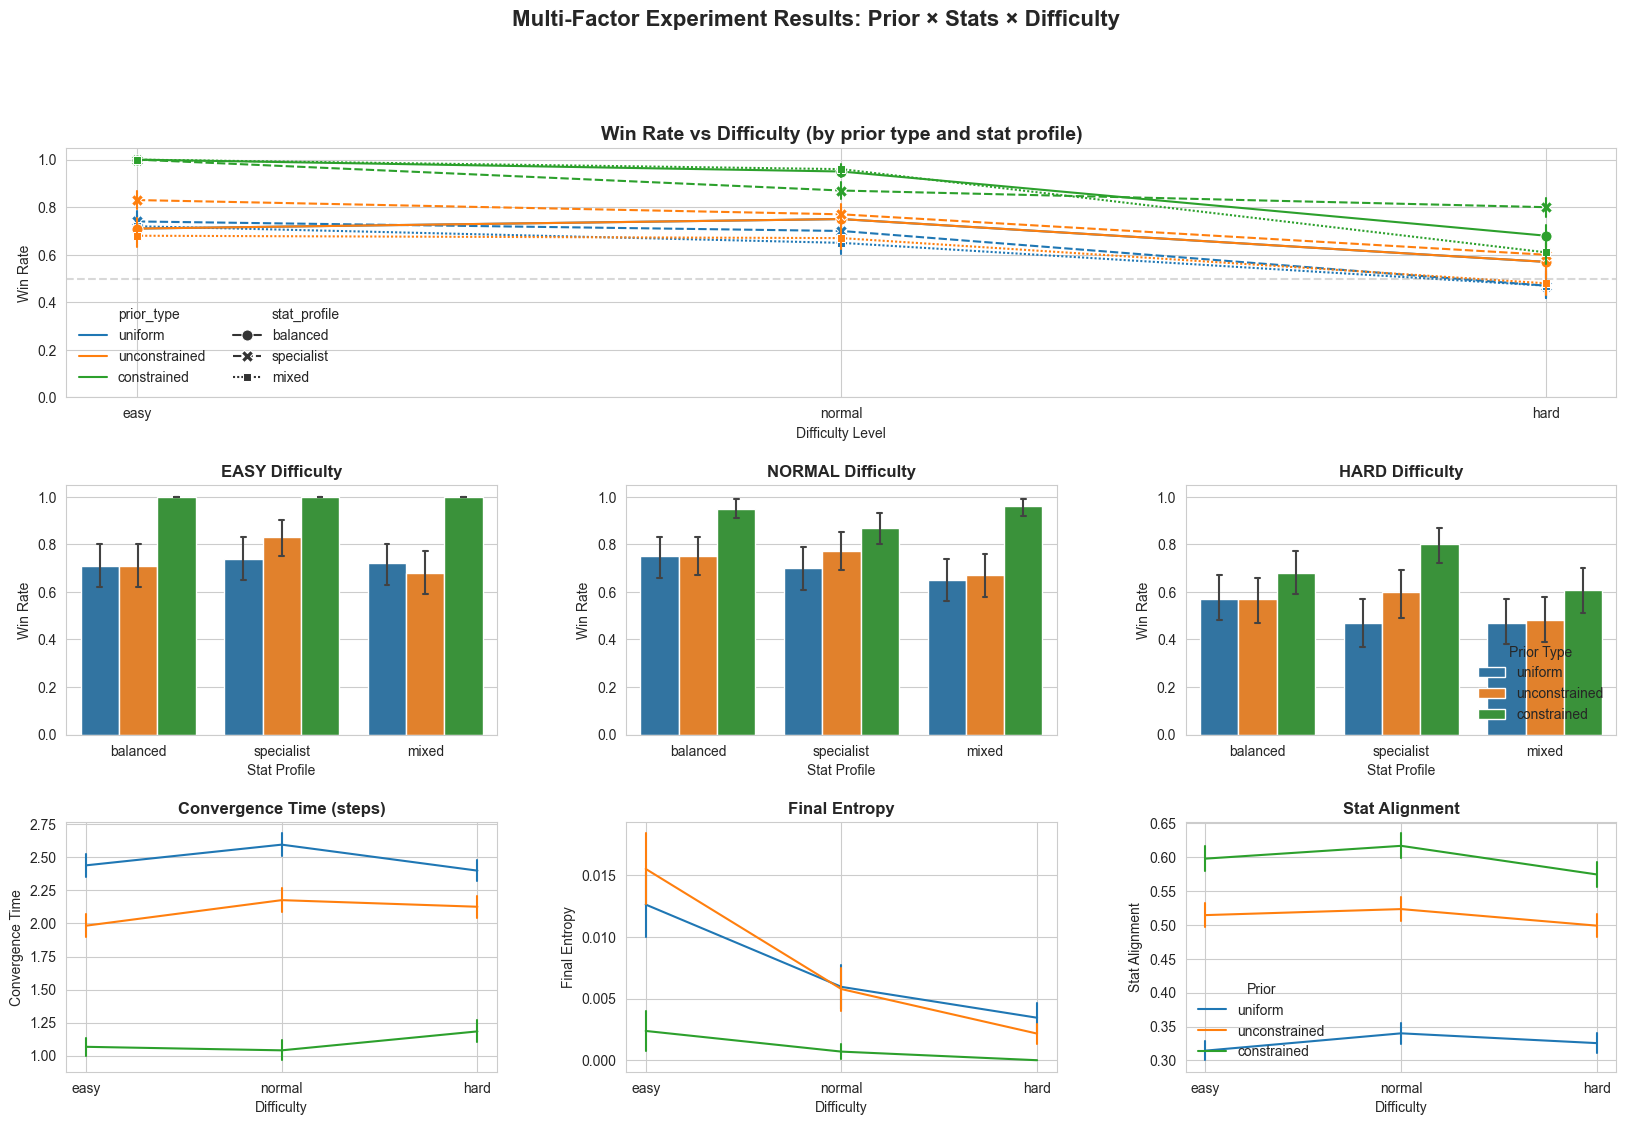

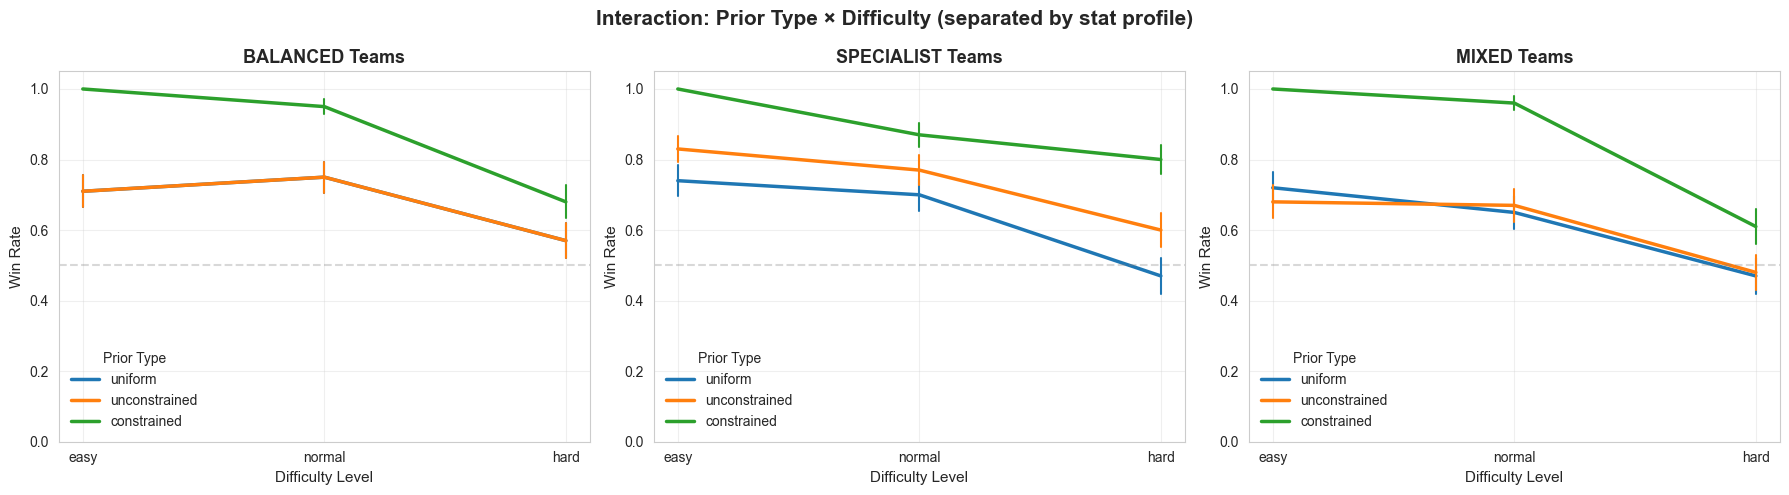

In [809]:
import seaborn as sns
sns.set_style('whitegrid')

# Create a comprehensive multi-panel visualization
fig = plt.figure(figsize=(20, 12))
gs = fig.add_gridspec(3, 3, hspace=0.35, wspace=0.3)

# Panel 1: Win rate by difficulty (faceted by stat profile)
ax1 = fig.add_subplot(gs[0, :])
sns.lineplot(
    data=experiment_results,
    x='difficulty',
    y='win',
    hue='prior_type',
    style='stat_profile',
    markers=True,
    markersize=8,
    ax=ax1,
    err_style='bars',
    errorbar=('se', 1)
)
ax1.set_title('Win Rate vs Difficulty (by prior type and stat profile)', fontsize=14, fontweight='bold')
ax1.set_xlabel('Difficulty Level')
ax1.set_ylabel('Win Rate')
ax1.legend(title='', frameon=False, ncol=2)
ax1.set_ylim([0, 1.05])
ax1.axhline(y=0.5, color='gray', linestyle='--', alpha=0.3, label='50% baseline')

# Panel 2: Win rate by prior × stat (faceted by difficulty)
for idx, difficulty in enumerate(['easy', 'normal', 'hard']):
    ax = fig.add_subplot(gs[1, idx])
    subset = experiment_results[experiment_results['difficulty'] == difficulty]
    
    sns.barplot(
        data=subset,
        x='stat_profile',
        y='win',
        hue='prior_type',
        ax=ax,
        errwidth=1.5,
        capsize=0.1
    )
    
    ax.set_title(f'{difficulty.upper()} Difficulty', fontsize=12, fontweight='bold')
    ax.set_xlabel('Stat Profile')
    ax.set_ylabel('Win Rate')
    if idx == 2:
        ax.legend(title='Prior Type', frameon=False, loc='lower right')
    else:
        ax.get_legend().remove()
    ax.set_ylim([0, 1.05])

# Panel 3: Convergence time and other metrics
metrics_to_plot = [
    ('convergence_time', 'Convergence Time (steps)'),
    ('final_entropy', 'Final Entropy'),
    ('stat_alignment', 'Stat Alignment'),
]

for idx, (metric, title) in enumerate(metrics_to_plot):
    ax = fig.add_subplot(gs[2, idx])
    
    # Show effect of difficulty on this metric, grouped by prior type
    sns.lineplot(
        data=experiment_results,
        x='difficulty',
        y=metric,
        hue='prior_type',
        markers=True,
        markersize=8,
        ax=ax,
        err_style='bars',
        errorbar=('se', 1)
    )
    
    ax.set_title(title, fontsize=12, fontweight='bold')
    ax.set_xlabel('Difficulty')
    ax.set_ylabel(title.split('(')[0].strip())
    if idx == 2:
        ax.legend(title='Prior', frameon=False)
    else:
        ax.get_legend().remove()

plt.suptitle('Multi-Factor Experiment Results: Prior × Stats × Difficulty', 
             fontsize=16, fontweight='bold', y=0.995)
plt.tight_layout()
plt.show()

# Additional plot: Interaction effects
fig2, axes = plt.subplots(1, 3, figsize=(18, 5))

# For each stat profile, show prior × difficulty interaction
for idx, stat_profile in enumerate(['balanced', 'specialist', 'mixed']):
    ax = axes[idx]
    subset = experiment_results[experiment_results['stat_profile'] == stat_profile]
    
    sns.lineplot(
        data=subset,
        x='difficulty',
        y='win',
        hue='prior_type',
        markers=True,
        markersize=10,
        ax=ax,
        err_style='bars',
        errorbar=('se', 1),
        linewidth=2.5
    )
    
    ax.set_title(f'{stat_profile.upper()} Teams', fontsize=13, fontweight='bold')
    ax.set_xlabel('Difficulty Level', fontsize=11)
    ax.set_ylabel('Win Rate', fontsize=11)
    ax.legend(title='Prior Type', frameon=False, fontsize=10)
    ax.set_ylim([0, 1.05])
    ax.axhline(y=0.5, color='gray', linestyle='--', alpha=0.3)
    ax.grid(True, alpha=0.3)

plt.suptitle('Interaction: Prior Type × Difficulty (separated by stat profile)', 
             fontsize=15, fontweight='bold')
plt.tight_layout()
plt.show()